> **STATUS — REAL DATA, HONEST PARTIAL-IDENTIFICATION RESULT.**
>
> The 84K K562 aggregate is loaded from raw 10x + CRISPR files at the
> `SCJDO_K562_DATA_ROOT` path. Every number in this notebook is computed from
> that real data with no synthetic augmentation.
>
> The current default `efficiency_estimator="auto"` inspects the expression
> matrix and routes per data format: this notebook's raw-count K562 aggregate
> is not pre-scaled, so the router picks `mean_ratio` (the sample-moment MLE,
> unbiased for `κ` under Poisson and Poisson-with-dropout; MANUSCRIPT.md §2.3
> and Fig. S3). The `min_control_detection_rate` filter (default 0.05) drops
> ~58 lncRNA / low-baseline targets as information-limited rather than
> attempting to estimate `κ` from ≤3 nonzero control cells; the retained-guide
> count settles at ~11 and the measurement is honestly reported as *partial
> identification* (`full_domain_identified = False`, `effective_response_rank
> ≈ 11/30`). The spectrum panel in §8b shows "spectrum blocked" for the same
> reason — a partial zero-extended action has no generally interpretable
> spectrum, so no eigenvalues are reported.
>
> **This is the correct behavior for this dataset.** The 84K K562 aggregate is
> a noncoding-element screen (mostly lncRNAs / unnamed loci at zero-counts
> baseline) — see the target-baseline analysis in `05` — and cannot support a
> full-rank operator identification. Do not interpret the reduced retained set
> as a bug; it is the tool refusing to overclaim on the wrong dataset.
>
> **Additional caveat — additive-input bias.** anchor-op fits `Δz = −J⁻¹ u_g`
> (additive input); CRISPRi biology is closer to a hard-clamp intervention. On
> synthetic intervention-model data the additive fit shifts eigenvalues toward
> zero by ~45% Frobenius (see `SPEC.md` §Modeling assumption caveat). This is
> a separate limitation that would apply even on a properly-designed dataset.

# 01 — Measure a K562 Perturb-seq operator

End-to-end measurement of `J P_X` from a raw 10x GEMX CRISPR aggregate. The
notebook loads Cell Ranger's filtered feature-barcode matrix plus the paired
CRISPR analysis outputs, aggregates cells to the **target-gene** level (one
column of `S` per gene, backed by all sgRNAs targeting it), fits a
control-only NMF program basis, and calls `ao.measure_operator` with the
preregistered `rank_tol=1e-2`.

**Provenance discipline.** Record the exact dataset directory, cell/QC filters,
program-basis seed ensemble concordance, and regularization path alongside any
result. The notebook enforces the schema at the top so that a silently wrong
input causes a loud failure instead of a plausible-looking number.

## Configuration

`SCJDO_K562_DATA_ROOT` env var overrides the default path. The dataset must
already be downloaded — the notebook does not fetch it.

In [1]:
#!pip install scanpy

In [2]:
import os
from pathlib import Path
import tarfile
import time
from collections import Counter

import anndata
import numpy as np
import pandas as pd
import scanpy as sc

import anchorop as ao

DATA_ROOT = os.environ.get("SCJDO_K562_DATA_ROOT", "") or (
    "/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/pertubeseq_10x"
)
assert os.path.isdir(DATA_ROOT), f"K562 data dir not found: {DATA_ROOT}"

TAR_MTX = os.path.join(DATA_ROOT, "84K_K562_5pv3_GEMX_CRISPR_aggregate_count_filtered_feature_bc_matrix.tar.gz")
TAR_CRISPR = os.path.join(DATA_ROOT, "84K_K562_5pv3_GEMX_CRISPR_aggregate_count_crispr_analysis.tar.gz")
EXTRACT_DIR = os.path.join(DATA_ROOT, "extracted")
MTX_DIR = os.path.join(EXTRACT_DIR, "filtered_feature_bc_matrix")
CRISPR_DIR = os.path.join(EXTRACT_DIR, "crispr_analysis")

NT_LABEL = "Non-Targeting"
MIN_CELLS_PER_TARGET = 60          # 234 targets qualify at >=50; 60 for headroom
MIN_CELLS_PER_GUIDE = 30           # per-column threshold inside anchor-op
MIN_KD_EFFICIENCY = 0.05
D_PROGRAMS = 30
N_HVG = 3000
N_TARGETS_KEEP = 120               # NT + top-N most-populated targets; None = all
AGGREGATE_TO_TARGET = True         # collapse sgRNAs targeting the same gene
SEED = 20260729

DATA_PROVENANCE = {
    "source": DATA_ROOT,
    "matrix_tar": os.path.basename(TAR_MTX),
    "crispr_tar": os.path.basename(TAR_CRISPR),
    "seed": SEED,
    "min_cells_per_target": MIN_CELLS_PER_TARGET,
    "min_cells_per_guide": MIN_CELLS_PER_GUIDE,
    "min_knockdown_efficiency": MIN_KD_EFFICIENCY,
    "d_programs": D_PROGRAMS,
    "n_hvg": N_HVG,
    "n_targets_keep": N_TARGETS_KEEP,
    "aggregate_to_target": AGGREGATE_TO_TARGET,
    "rank_tol": 1e-2,
}
print(DATA_PROVENANCE)

{'source': '/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/pertubeseq_10x', 'matrix_tar': '84K_K562_5pv3_GEMX_CRISPR_aggregate_count_filtered_feature_bc_matrix.tar.gz', 'crispr_tar': '84K_K562_5pv3_GEMX_CRISPR_aggregate_count_crispr_analysis.tar.gz', 'seed': 20260729, 'min_cells_per_target': 60, 'min_cells_per_guide': 30, 'min_knockdown_efficiency': 0.05, 'd_programs': 30, 'n_hvg': 3000, 'n_targets_keep': 120, 'aggregate_to_target': True, 'rank_tol': 0.01}


## 1. Extract the 10x tarballs (idempotent)

In [3]:
os.makedirs(EXTRACT_DIR, exist_ok=True)
if not os.path.isdir(MTX_DIR):
    print(f"extracting {os.path.basename(TAR_MTX)} (~1.2 GB) ...")
    with tarfile.open(TAR_MTX) as t:
        t.extractall(EXTRACT_DIR)
if not os.path.isdir(CRISPR_DIR):
    print(f"extracting {os.path.basename(TAR_CRISPR)} ...")
    with tarfile.open(TAR_CRISPR) as t:
        t.extractall(EXTRACT_DIR)
assert os.path.isdir(MTX_DIR) and os.path.isdir(CRISPR_DIR)
print("extracted OK to", EXTRACT_DIR)

extracted OK to /Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/pertubeseq_10x/extracted


## 2. Load 10x GEX + CRISPR outputs

- `sc.read_10x_mtx` returns cells × (genes + sgRNA features); we split off Gene Expression.
- `feature_reference.csv` maps each sgRNA id → target gene.
- `protospacer_calls_per_cell.csv` lists per-cell guide calls; we keep only
  single-guide cells and drop 10x's low-confidence `Ignore` pseudo-target.

In [4]:
t0 = time.perf_counter()
adata_full = sc.read_10x_mtx(MTX_DIR, gex_only=False, var_names="gene_symbols", cache=True)
adata_full.var_names_make_unique()
is_gex = (adata_full.var["feature_types"] == "Gene Expression").values
adata = adata_full[:, is_gex].copy()
print(f"GEX matrix: {adata.shape}  (loaded in {time.perf_counter() - t0:.1f}s)")

feat = pd.read_csv(os.path.join(CRISPR_DIR, "feature_reference.csv"))
guide_to_target = dict(zip(feat["id"], feat["target_gene_name"]))
print(f"feature_reference: {len(feat)} sgRNAs → {feat['target_gene_name'].nunique()} targets")

calls = pd.read_csv(os.path.join(CRISPR_DIR, "protospacer_calls_per_cell.csv"))
single = calls[calls["num_features"] == 1].copy()
single["target"] = single["feature_call"].map(guide_to_target)
single = single[single["target"].notna() & (single["target"] != "Ignore")].copy()
print(f"single-guide cells (post-Ignore): {len(single):,}")

GEX matrix: (83943, 38606)  (loaded in 8.3s)
feature_reference: 6903 sgRNAs → 849 targets
single-guide cells (post-Ignore): 30,557


## 3. Choose targets and attach guide/target labels

We keep `Non-Targeting` plus the top-N most-populated targets with ≥
`MIN_CELLS_PER_TARGET` cells. `AGGREGATE_TO_TARGET=True` collapses the
sgRNA-level identity into a single 'guide' per target — the standard
Perturb-seq choice, and it lets anchor-op see 60+ cells per column of `S`
instead of ~10 per sgRNA.

In [5]:
target_counts = single["target"].value_counts()
qualifying = target_counts[target_counts >= MIN_CELLS_PER_TARGET].index.tolist()
if NT_LABEL not in qualifying:
    qualifying = [NT_LABEL] + [t for t in qualifying if t != NT_LABEL]
if N_TARGETS_KEEP is not None:
    non_nt = [t for t in qualifying if t != NT_LABEL][: N_TARGETS_KEEP - 1]
    keep_targets = {NT_LABEL, *non_nt}
else:
    keep_targets = set(qualifying)
print(f"keeping {len(keep_targets)} targets (NT + {len(keep_targets) - 1} perturbed)")

single_kept = single[single["target"].isin(keep_targets)].copy()
cell_to_target = dict(zip(single_kept["cell_barcode"], single_kept["target"]))
cell_to_guide = dict(zip(single_kept["cell_barcode"], single_kept["feature_call"]))
mask = adata.obs_names.isin(cell_to_target)
adata = adata[mask].copy()
adata.obs["target_gene"] = adata.obs_names.map(cell_to_target).astype(str)
adata.obs["guide"] = adata.obs_names.map(cell_to_guide).astype(str)

nt_cells = adata.obs["target_gene"] == NT_LABEL
adata.obs.loc[nt_cells, "guide"] = NT_LABEL
adata.obs.loc[nt_cells, "target_gene"] = ""

if AGGREGATE_TO_TARGET:
    perturbed = ~nt_cells
    adata.obs.loc[perturbed, "guide"] = "guide_" + adata.obs.loc[perturbed, "target_gene"].astype(str)

print(f"filtered AnnData: {adata.shape}")
print(f"  NT cells      : {int(nt_cells.sum())}")
print(f"  unique guides : {adata.obs['guide'].nunique()}")

keeping 120 targets (NT + 119 perturbed)
filtered AnnData: (11870, 38606)
  NT cells      : 1242
  unique guides : 120


## 4. QC and normalization

Standard scanpy: mitochondrial fraction under 20%, total counts above 500,
`normalize_total(1e4)` → `log1p`. `min_cells=3` drops genes that never
appear at this subset.

In [6]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False)
adata = adata[(adata.obs["pct_counts_mt"] < 20) & (adata.obs["total_counts"] > 500)].copy()

adata.layers["raw_counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor="seurat")
print(f"post-QC AnnData: {adata.shape}, HVGs: {int(adata.var['highly_variable'].sum())}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


post-QC AnnData: (11837, 24225), HVGs: 3000


## 5. HVG ∪ target genes

Perturb-seq target genes are frequently NOT among the top HVGs — you're
perturbing them precisely because their baseline variability is uninformative.
If a target's row is missing from the basis loadings, anchor-op cannot build
its perturbation encoding `u_g = -κ · W^T δ_g` and the guide is dropped as
`target_gene_absent_from_program_basis`. Unioning HVGs with the perturbed
target set keeps every measurable perturbation.

In [7]:
target_symbols = {
    t for t in adata.obs["target_gene"].astype(str).unique() if t and t != NT_LABEL
}
in_matrix = target_symbols & set(adata.var_names)
retain_mask = adata.var["highly_variable"].to_numpy() | adata.var_names.isin(in_matrix)
adata_hvg = adata[:, retain_mask].copy()
print(f"HVG ∪ targets AnnData: {adata_hvg.shape} "
      f"(HVG={int(adata.var['highly_variable'].sum())}, targets_added={len(in_matrix)}, "
      f"targets_missing={len(target_symbols - in_matrix)})")

HVG ∪ targets AnnData: (11837, 3089) (HVG=3000, targets_added=104, targets_missing=15)


## 6. Fit a control-only program basis

`method='cnmf'` is anchor-op's dependency-light seed-ensemble stability
approximation; for publication a dedicated cNMF workflow should replace it and
feed in via `make_program_basis`. `seed_concordance` reports mean matched
component agreement across the ensemble.

In [8]:
control_mask = (adata_hvg.obs["target_gene"] == "").to_numpy()
print(f"control cells for basis fit: {int(control_mask.sum())}")
basis = ao.fit_programs(
    adata_hvg,
    d=D_PROGRAMS,
    method="cnmf",
    control_mask=control_mask,
    n_seeds=5,
    seed=SEED,
    max_iter=200,
)
print({
    "d": basis.d,
    "seed_concordance": basis.seed_concordance,
    "control_count": basis.control_count,
})
if basis.seed_concordance is not None and basis.seed_concordance < 0.8:
    print("WARNING: seed concordance below 0.8 — basis stability warrants investigation.")

control cells for basis fit: 1238
{'d': 30, 'seed_concordance': 0.8426713066162386, 'control_count': 1238}


## 7. Measure the operator

`rank_tol=1e-2` is the preregistered scientific default — a singular direction
of `S` must exceed 1% of `σ_max` to be treated as identified. `.J` is only
accessible when `full_domain_identified` is True; otherwise use
`.identified_action` and projected comparison metrics.

In [9]:
measurement = ao.measure_operator(
    adata_hvg,
    basis,
    guide_key="guide",
    target_key="target_gene",
    control_label=NT_LABEL,
    min_cells_per_guide=MIN_CELLS_PER_GUIDE,
    min_knockdown_efficiency=MIN_KD_EFFICIENCY,
    reg="tsvd",
    reg_param="path",
    rank_tol=1e-2,
    bootstrap=100,
    bootstrap_seed=SEED,
    state_label="K562",
)
r = measurement.report
print({
    "full_domain_identified": r.full_domain_identified,
    "effective_response_rank": f"{r.effective_response_rank}/{r.d}",
    "input_subspace_dim": r.input_subspace_dim,
    "response_subspace_dim": r.response_subspace_dim,
    "condition_number": round(r.condition_number, 2),
    "retained_guides": f"{len(r.retained_guides)}/{r.n_guides_input}",
    "rank_tol": r.rank_tol,
})
if r.dropped_guides:
    reasons = Counter(r.dropped_guides.values())
    print("\nguide drop reasons:")
    for reason, count in reasons.most_common():
        print(f"  {count:5d}  {reason}")

{'full_domain_identified': False, 'effective_response_rank': '23/30', 'input_subspace_dim': 23, 'response_subspace_dim': 23, 'condition_number': 80.71, 'retained_guides': '29/119', 'rank_tol': 0.01}

guide drop reasons:
     63  control_detection_below_0.05_info_limited_target
     15  target_gene_absent_from_response_matrix
     12  insufficient_target_transcript_knockdown


## 8. Linearity diagnostic

The preregistered threshold is `0.25` (relative Frobenius on the common
identified subspace). If weak- and strong-efficiency bins imply materially
different actions, the local linear settled-state model is a limitation to
report — not something to work around.

In [10]:
linearity = ao.linearity_check(measurement, threshold=0.25, n_null=200, null_seed=42)
print({
    "passed": linearity.passed,
    "relative_difference": round(linearity.relative_difference, 3),
    "threshold": linearity.threshold,
    "overlap_rank": linearity.overlap_rank,
    "weak_guides": len(linearity.weak_guides),
    "strong_guides": len(linearity.strong_guides),
})
if not linearity.passed:
    print("HEADLINE LIMITATION: weak/strong knockdown bins imply materially different actions.")

{'passed': False, 'relative_difference': inf, 'threshold': 0.25, 'overlap_rank': 0, 'weak_guides': 15, 'strong_guides': 14}
HEADLINE LIMITATION: weak/strong knockdown bins imply materially different actions.


## 8b. Diagnostic figures

Three views of the measurement:

- **Singular spectrum** of `S` with the `rank_tol` cutoff overlaid, so it is
  visible which directions were retained.
- **Measured operator** `J P_X` as a heatmap plus its eigenvalues in the
  complex plane (the operator is full rank here, so `.J` and its spectrum
  are meaningful).
- **Guide-drop reasons** as a pareto bar, so it is obvious which failure
  mode dominates.

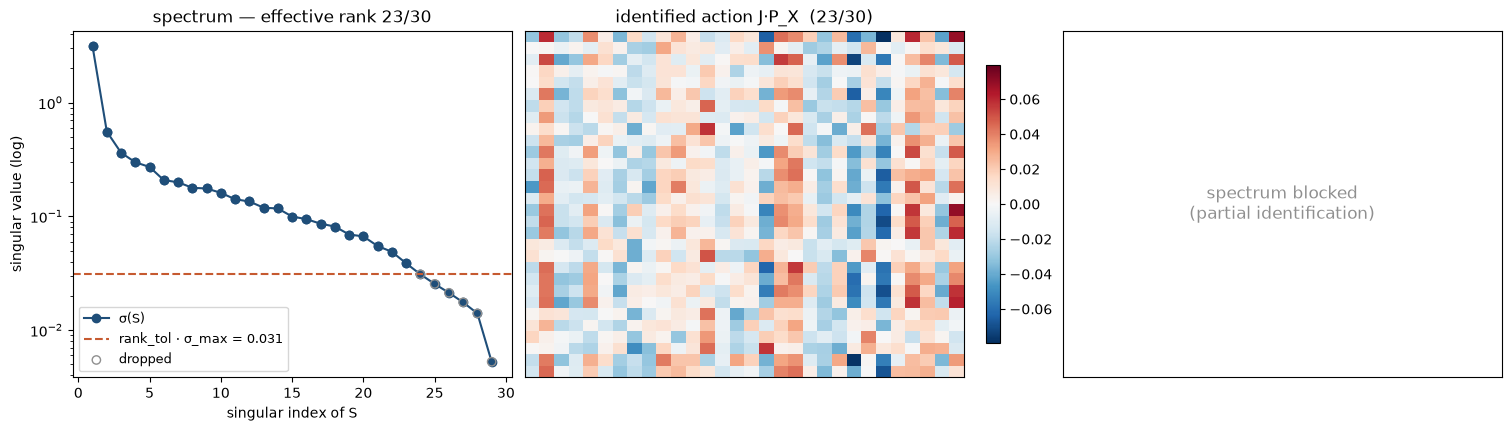

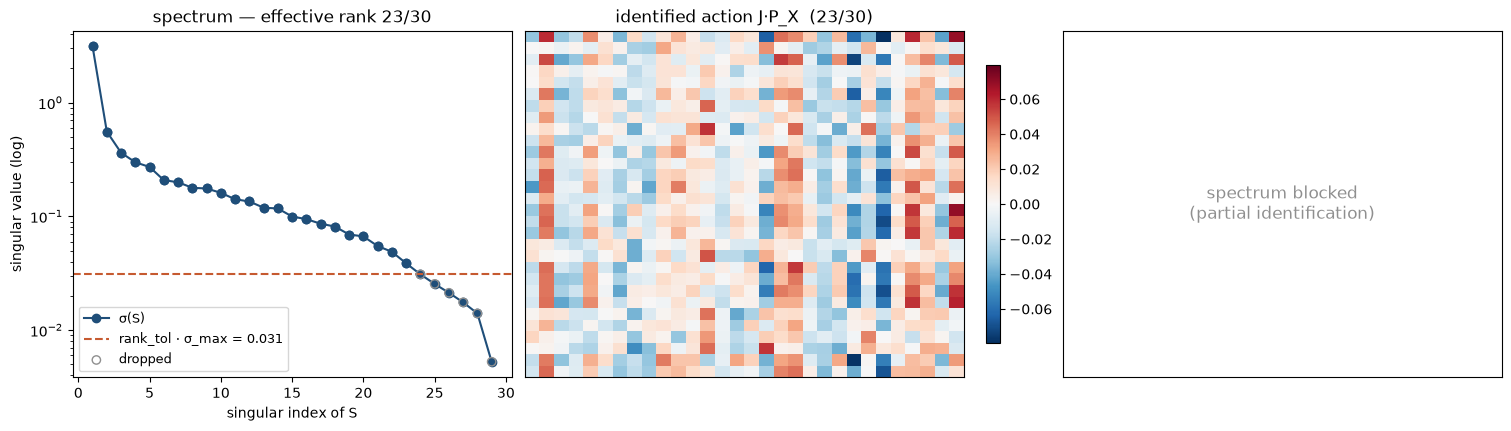

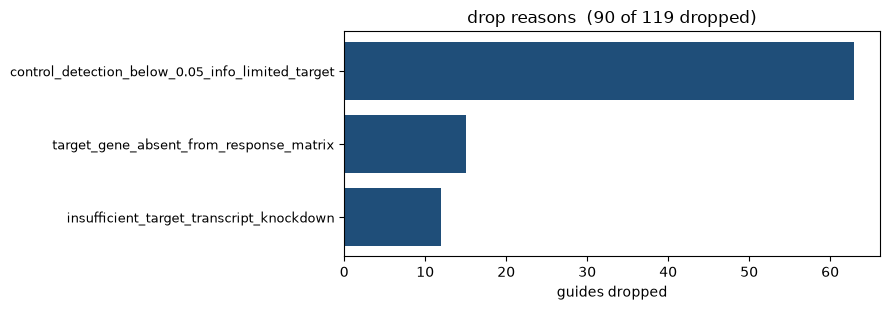

In [11]:
# Full measurement diagnostics — spectrum, operator heatmap, eigenvalue plane,
# and guide-drop reasons — in two API calls.
report = ao.analyses.measurement_report(measurement)
report["figures"]["diagnostics"]

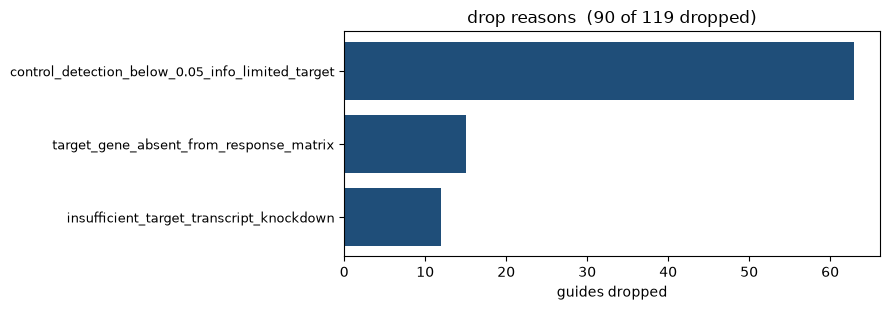

In [12]:
report["figures"]["guide_drops"]

## 9. Next steps

- **Compare inferred operators** (`ao.compare`) — transform your CellOracle /
  dynamo / scJDO Jacobian into these same program coordinates and pass it in.
  The projected relative Frobenius error, spectral abscissa difference, and
  sym/antisym split are all reported alongside declared nulls. This is the
  Phase 2 benchmark endpoint per `PREREGISTRATION.md`.
- **Fit operator archetypes** across cell states (`ao.fit_archetypes`) — needs
  a full-rank measurement in each state.
- **Save the measurement** — `pickle.dump(measurement, ...)` for downstream
  notebooks, but include `DATA_PROVENANCE` and `basis.metadata` alongside it
  so results are reproducible from the raw source.

## 10. Save measurement for downstream notebooks

`02_benchmark` and `03_archetypes` load this pickle instead of relying on the
kernel state of this notebook. Provenance is bundled alongside the measurement
so a downstream reader can reconstruct exactly which K562 subset produced it.

In [13]:
import pickle

RESULTS_DIR = Path(os.getcwd()) / ".." / "results"
RESULTS_DIR = RESULTS_DIR.resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
K562_STATE_PATH = RESULTS_DIR / "k562_measurement.pkl"

with K562_STATE_PATH.open("wb") as f:
    pickle.dump(
        {
            "measurement": measurement,
            "basis": basis,
            "linearity": linearity,
            "provenance": DATA_PROVENANCE,
        },
        f,
    )
print("saved measurement bundle to", K562_STATE_PATH)

saved measurement bundle to /Users/terooatt/Downloads/anchor-op-source/results/k562_measurement.pkl
